<a href="https://colab.research.google.com/github/yeekrim/sla600-log-analyzer/blob/main/SLA_MovementGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. 로그 파일 경로 지정 (예시 경로: 내 드라이브 > Logs > your_log_file.log)
log_file_path = '/content/drive/MyDrive/SLA/20250403-010249-163.log'

# 3. 파일 읽기
with open(log_file_path, 'r', encoding='utf-8') as f:
    log_lines = f.readlines()

# 4. 상위 10줄 확인
for line in log_lines[:10]:
    print(line.strip())

[Info] -> ---------- Print Start ----------
[Info] -> 2025-04-03 01:02:49.284  Start Manu
[Info] -> 2025-04-03 01:02:49.284  Laser 1 Beam Axis is disabled
[Info] -> 2025-04-03 01:02:49.299  Interp Level 0 Start
[Info] -> 2025-04-03 01:02:49.299  7092-CPrintCraftGenerator::getCraftData--998  craft function In
[Info] -> 2025-04-03 01:02:49.302  7092-CPrintCraftGenerator::getCraftData--1000  craft function Out
[Info] -> 2025-04-03 01:02:49.302  Interp Level 0 Done
[Info] -> 2025-04-03 01:02:49.315  Interp Level 1 Start
[Info] -> 2025-04-03 01:02:49.315  Start Manu Level 0
[Info] -> 2025-04-03 01:02:49.315  7092-CPrintCraftGenerator::getCraftData--998  craft function In


# **빌드 플레이트 (axis 0) 움직임 시계열**

In [ ]:
# 필터링된 줄만 저장할 리스트
axis0_lines = [line.strip() for line in log_lines if "Axis 0" in line or "Elevator" in line]

# 결과 확인 (상위 10줄만)
for line in axis0_lines[:10]:
    print(line)

[Info] -> 2025-04-03 01:02:50.218  Elevator Go Origin Start
[Info] -> 2025-04-03 01:02:56.935  Elevator Go Origin Done
[Info] -> 2025-04-03 01:02:56.951  Axis 0 Move Abs Pos: 57.5 Speed: 5 Current Pos 0
[Info] -> 2025-04-03 01:02:56.951  Elevator Move To Resin Check Height
[Info] -> 2025-04-03 01:03:08.503  Elevator Move To Resin Check Done
[Info] -> 2025-04-03 01:03:10.590  Axis 0 Move Abs Pos: 67.5 Speed: 5 Current Pos 57.5
[Info] -> 2025-04-03 01:03:10.590  Elevator Move To Remove Bubbles Height
[Info] -> 2025-04-03 01:03:12.645  Elevator Move To Remove Bubbles Height Done
[Info] -> 2025-04-03 01:04:17.658  Axis 0 Move Abs Pos: 57.5 Speed: 1 Current Pos 67.5
[Info] -> 2025-04-03 01:04:17.658  Elevator Move Down Level Thickness


In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime
import re

timestamps0 = []
positions0 = []

time_match = re.search(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}", log_lines[1])
time_str = time_match.group()
time_obj = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S.%f")
timestamps0.append(time_obj)
positions0.append(0)

for line in axis0_lines:
    # 시간 추출 (예: 2025-03-13 17:23:01.985)
    time_match = re.search(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}", line)

    # Current Pos 추출 (예: Current Pos 57)
    if time_match and "Abs Pos" in line:
      pos_match = re.search(r"Abs Pos:\s*([-\d\.]+)", line)
      pos = float(pos_match.group(1))
    elif time_match and "Go Origin" in line:
      pos = 0

    time_str = time_match.group()
    time_obj = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S.%f")

    timestamps0.append(time_obj)
    positions0.append(pos)

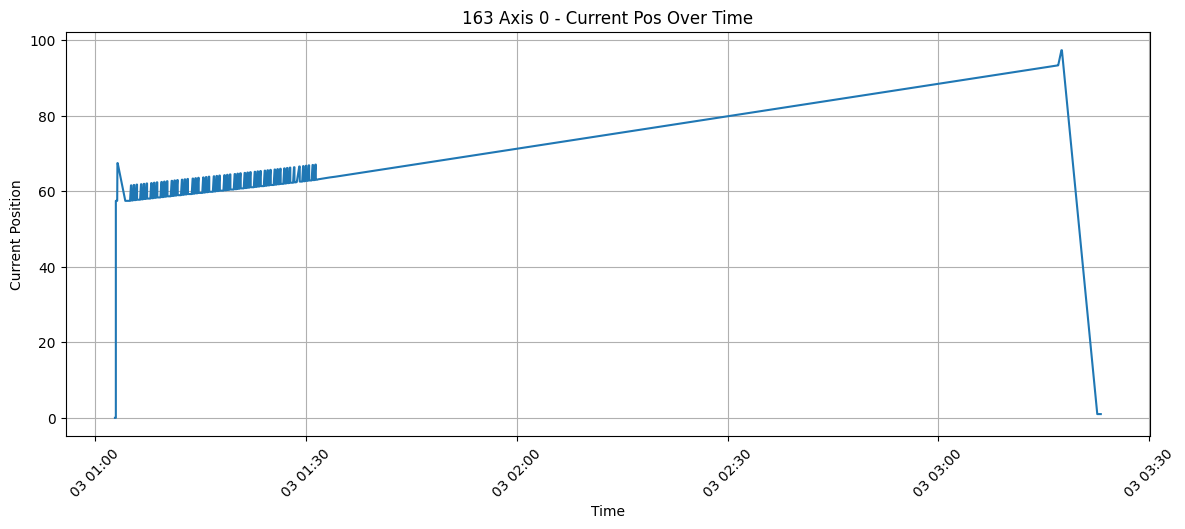

In [ ]:
# 3. 시각화
plt.figure(figsize=(12, 5))
plt.plot(timestamps0, positions0)
plt.title('163 Axis 0 - Current Pos Over Time')
plt.xlabel('Time')
plt.ylabel('Current Position')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# **리코터 (axis 1) 움직임 시계열**

In [ ]:
# 필터링된 줄만 저장할 리스트
axis1_lines = [line.strip() for line in log_lines if "Axis 1" in line or "Recoater" in line]

# 결과 확인 (상위 10줄만)
for line in axis1_lines[:10]:
    print(line)

[Info] -> 2025-04-03 01:02:49.486  Recoater Go Origin Start
[Info] -> 2025-04-03 01:02:50.202  Recoater Go Origin Done
[Info] -> 2025-04-03 01:03:34.490  Axis 1 Move Rel Length: 2000 Speed: 50 Current Pos 0
[Info] -> 2025-04-03 01:03:47.688  Update Recoater Positive Limit
[Info] -> 2025-04-03 01:03:47.704  Axis 1 Move Rel Length: -2000 Speed: 80 Current Pos 636.608
[Info] -> 2025-04-03 01:03:56.052  Axis 1 Move Rel Length: 2000 Speed: 50 Current Pos -0.187407
[Info] -> 2025-04-03 01:04:09.236  Update Recoater Positive Limit
[Info] -> 2025-04-03 01:04:09.252  Axis 1 Move Rel Length: -2000 Speed: 80 Current Pos 636.608
[Info] -> 2025-04-03 01:28:42.086  Axis 1 Move Abs Pos: 238 Speed: 40 Current Pos -0.187407
[Info] -> 2025-04-03 01:28:42.086  Recoater Start Move


In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime
import re

timestamps1 = []
positions1 = []

for line in axis1_lines:
    # 시간 추출 (예: 2025-03-13 17:23:01.985)
    time_match = re.search(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}", line)
    time_str = time_match.group()
    time_obj = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S.%f")

    # Current Pos 추출 (예: Current Pos 57)
    if time_match and "Current Pos" in line:
      pos_match = re.search(r"Current Pos\s+(-?[\d\.]+)", line)
      pos = float(pos_match.group(1))
      timestamps1.append(time_obj)
      positions1.append(pos)
    elif time_match and "Go Origin" in line:
      pos = 0
      timestamps1.append(time_obj)
      positions1.append(pos)
    else :
      pass

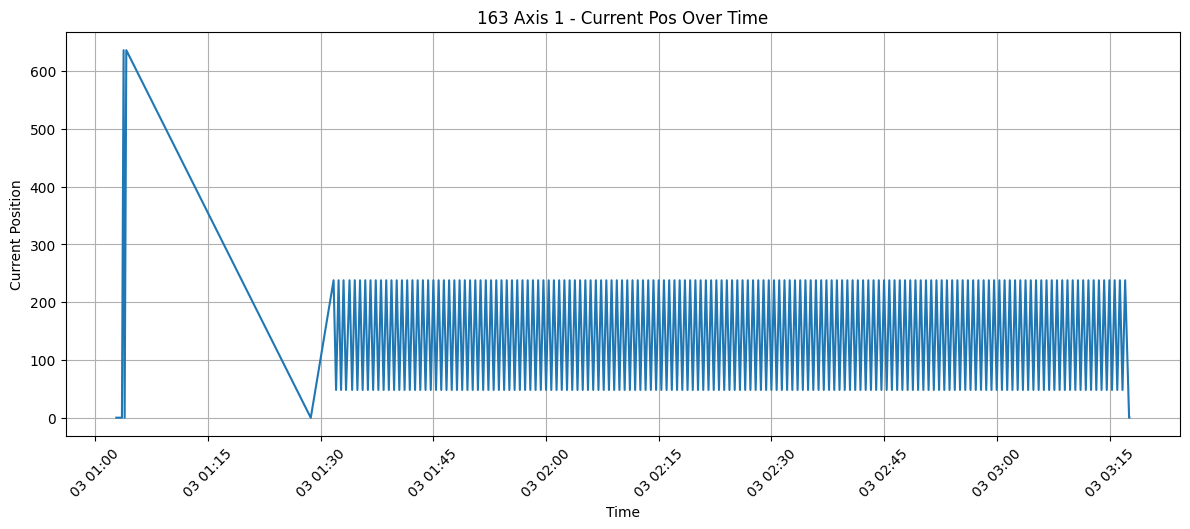

In [ ]:
# 3. 시각화
plt.figure(figsize=(12, 5))
plt.plot(timestamps1, positions1)
plt.title('163 Axis 1 - Current Pos Over Time')
plt.xlabel('Time')
plt.ylabel('Current Position')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# **레진블럭 (axis 2) 움직임 시계열**

In [ ]:
# 필터링된 줄만 저장할 리스트
axis2_lines = [line.strip() for line in log_lines if "Before" in line or "After" in line]

# 결과 확인 (상위 10줄만)
for line in axis2_lines[:10]:
    print(line)

[Info] -> 2025-04-03 01:03:08.534  Delay 2000ms Before Resin Check
[Info] -> 2025-04-03 01:03:10.543  Delay Before Resin Check Done
[Info] -> 2025-04-03 01:03:12.661  Before Move Resin current position is 54.000, current level pos is -0.795, target level is 1.200
[Info] -> 2025-04-03 01:03:13.103  After Move Resin current position is 51.921, current level pos is 1.731, target level is 1.200
[Info] -> 2025-04-03 01:03:14.763  Before Move Resin current position is 51.921, current level pos is -0.798, target level is 1.200
[Info] -> 2025-04-03 01:03:15.521  After Move Resin current position is 48.256, current level pos is 2.649, target level is 1.200
[Info] -> 2025-04-03 01:03:17.226  Before Move Resin current position is 48.256, current level pos is -0.183, target level is 1.200
[Info] -> 2025-04-03 01:03:17.919  After Move Resin current position is 44.919, current level pos is 3.150, target level is 1.200
[Info] -> 2025-04-03 01:03:18.724  Before Move Resin current position is 44.919, c

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime
import re

timestamps2 = []
positions2 = []

for line in axis2_lines:
    # 시간 추출 (예: 2025-03-13 17:23:01.985)
    time_match = re.search(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}", line)
    time_str = time_match.group()
    time_obj = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S.%f")
    # Current Pos 추출 (예: Current Pos 57)
    if "Resin current position is" in line:
        pos_match = re.search(r"Resin current position is\s+([-\d\.]+)", line)
        if pos_match:
            position = float(pos_match.group(1))
            positions2.append(position)
            timestamps2.append(time_obj)


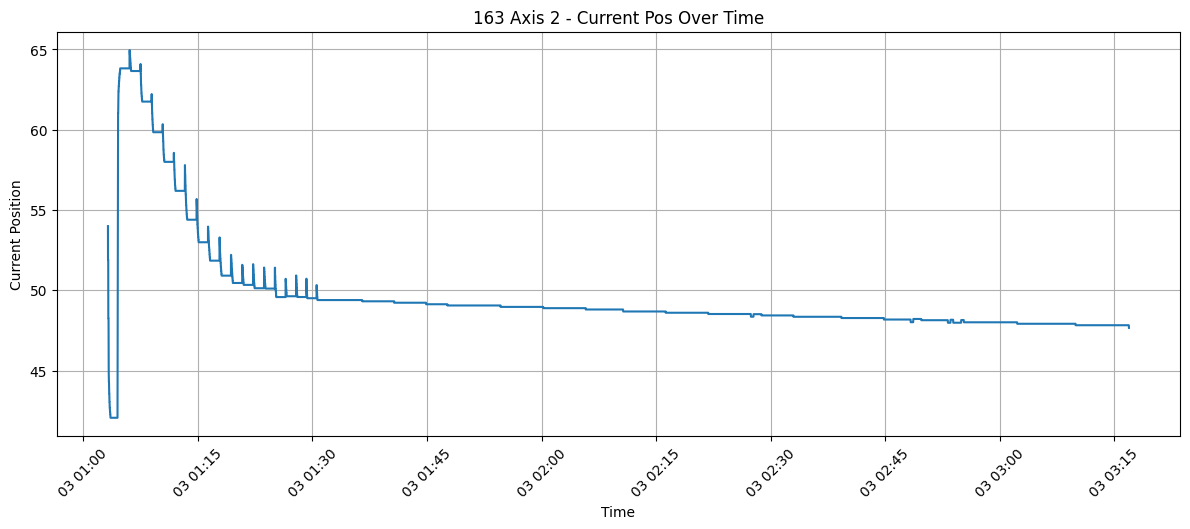

In [ ]:
# 3. 시각화
plt.figure(figsize=(12, 5))
plt.plot(timestamps2, positions2)
plt.title('163 Axis 2 - Current Pos Over Time')
plt.xlabel('Time')
plt.ylabel('Current Position')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# **레진레벨(Resin Level) 움직임 시계열**

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime
import re

timestamps_RL = []
positions_CRL = []
positions_TRL = []


for line in axis2_lines:
    # 시간 추출 (예: 2025-03-13 17:23:01.985)
    time_match = re.search(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}", line)
    time_str = time_match.group()
    time_obj = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S.%f")
    # Current Pos 추출 (예: Current Pos 57)
    if "Resin current position is" in line:
        pos_match = re.search(r"current level pos is\s+([-\d\.]+)", line)
        TRL_match = re.search(r"target level is\s+([-\d\.]+)", line)
        if pos_match and TRL_match:
            position_CRL = float(pos_match.group(1))
            position_TRL = float(TRL_match.group(1))
            positions_CRL.append(position_CRL)
            positions_TRL.append(position_TRL)
            timestamps_RL.append(time_obj)

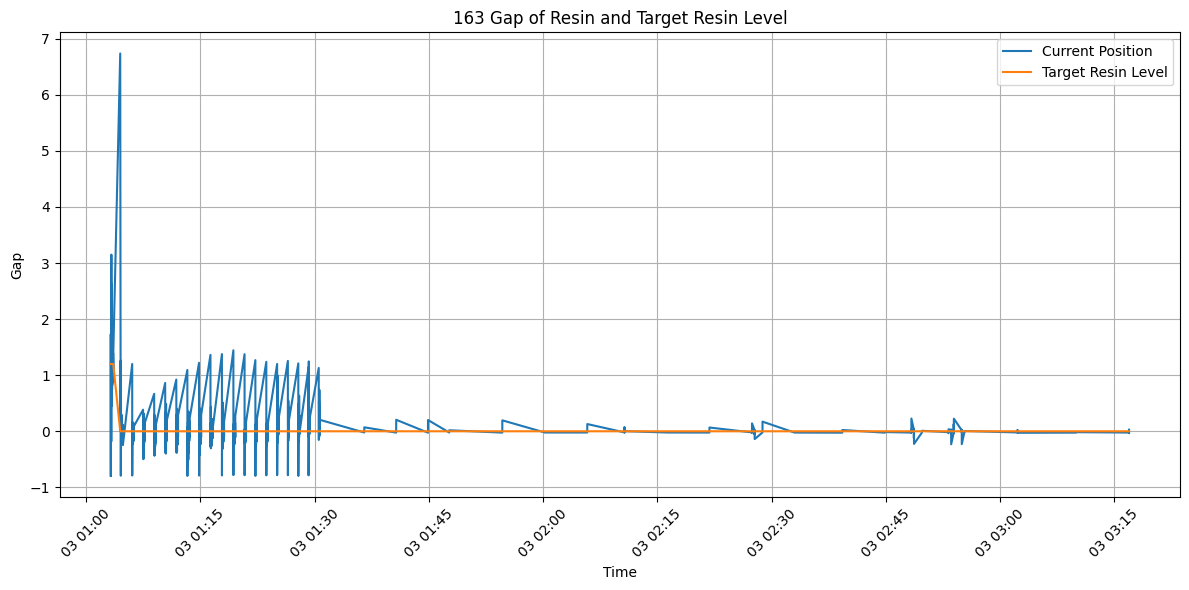

In [ ]:
import matplotlib.pyplot as plt

# 1. 시간축: timestamps
# 2. Y축 1: current_positions
# 3. Y축 2: target_levels

plt.figure(figsize=(12, 6))
plt.plot(timestamps_RL, positions_CRL, label='Current Position')
plt.plot(timestamps_RL, positions_TRL, label='Target Resin Level')

plt.title('163 Gap of Resin and Target Resin Level')
plt.xlabel('Time')
plt.ylabel('Gap')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()